ACC_X, ACC_Y, ACC_Z (Accelerometer)
Type: Motion sensor\
Unit: g (gravitational acceleration)

These three columns represent movement in 3D space.

| Feature | Positive (+)                        | Negative (−)                 |
| ---- | ----------------------------------- | ---------------------------- |
| ACC_X    | movement toward +X direction        | movement toward −X direction |
| ACC_Y    | movement toward +Y direction        | movement toward −Y direction |
| ACC_Z    | movement upward / toward sensor top | movement downward            |


**Why important for stress research**

Movement changes when people are stressed:
- stressed → restless movement
- calm → steady posture

Example:
```
ACC_X = 0.955
ACC_Y = -0.222
ACC_Z = -0.558
```
Interpretation:
- strong acceleration in +X
- slight movement in −Y
- moderate movement in −Z

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../Dataset/S2_chest_data.csv")
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return "stressed"
    elif label in nStr:
        return "not stressed"
    else:
        return "unknown"

df["target"] = df["Label"].apply(apply_target)

df.head(2)

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label,target
214583,0.8914,-0.1102,-0.2576,0.030945,-0.003708,5.710983,29.083618,1.191711,1,not stressed
214584,0.8926,-0.1086,-0.2544,0.033646,-0.014145,5.719376,29.122437,1.139832,1,not stressed


### EDA starts from here

In [10]:
df[["ACC_X", "ACC_Y", "ACC_Z"]].describe()

,ACC_X,ACC_Y,ACC_Z
count,2.022299e+06,2.022299e+06,2.022299e+06
mean,6.905893e-01,-1.254201e-01,-5.541978e-01
std,1.585121e-01,5.674518e-02,2.676459e-01
min,3.116000e-01,-4.194000e-01,-1.004000e+00
25%,6.046000e-01,-1.446000e-01,-7.346000e-01
50%,6.286000e-01,-1.240000e-01,-7.094000e-01
75%,8.760000e-01,-7.340002e-02,-2.814000e-01
max,1.380600e+00,2.024000e-01,1.041800e+00


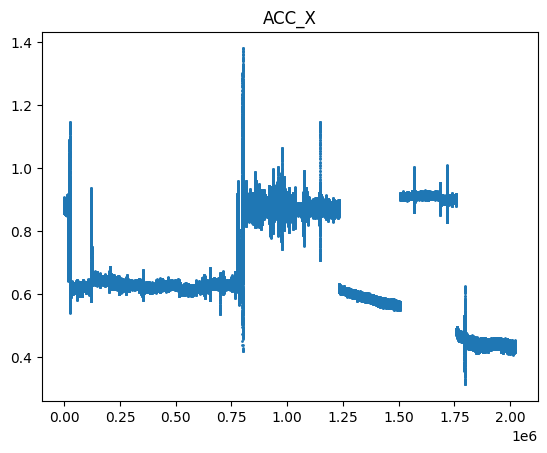

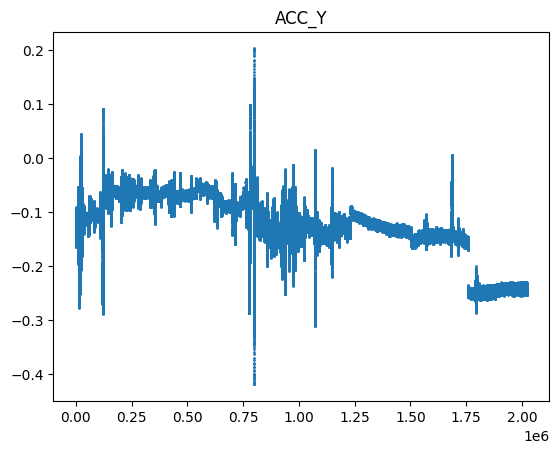

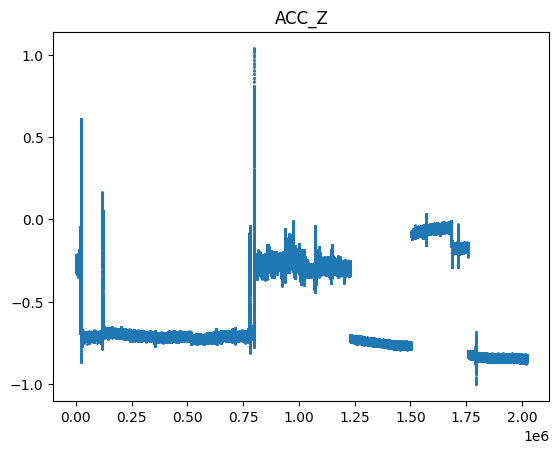

In [7]:
plt.scatter(range(len(df)), df["ACC_X"], s=1)
plt.title("ACC_X")
plt.show()

plt.scatter(range(len(df)), df["ACC_Y"], s=1)
plt.title("ACC_Y")
plt.show()

plt.scatter(range(len(df)), df["ACC_Z"], s=1)
plt.title("ACC_Z")
plt.show()

In [24]:
str_EDA = df[df["target"] == "stressed"]
nStr_EDA = df[df["target"] == "not stressed"]

>---------- stress class ---------<


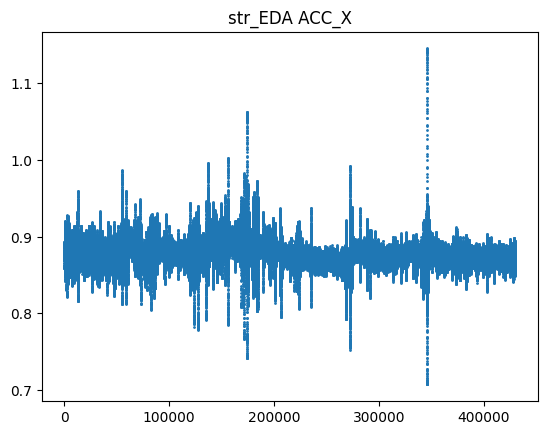

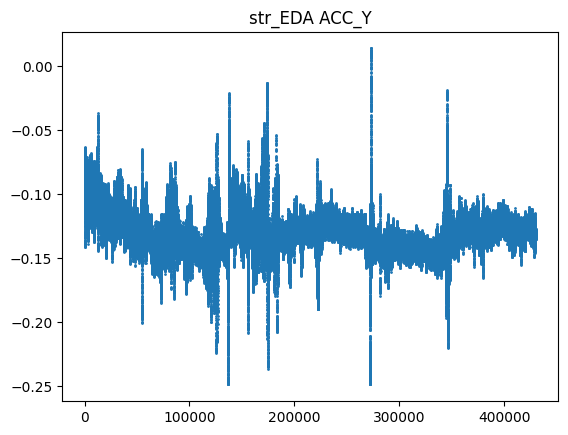

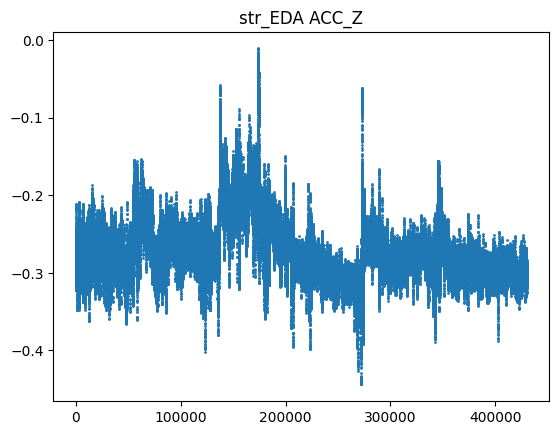

In [25]:
print(">---------- stress class ---------<")
plt.scatter(range(len(str_EDA)), str_EDA["ACC_X"], s=1)
plt.title("str_EDA ACC_X")
plt.show()

plt.scatter(range(len(str_EDA)), str_EDA["ACC_Y"], s=1)
plt.title("str_EDA ACC_Y")
plt.show()

plt.scatter(range(len(str_EDA)), str_EDA["ACC_Z"], s=1)
plt.title("str_EDA ACC_Z")
plt.show()

>---------- non stress class ---------<


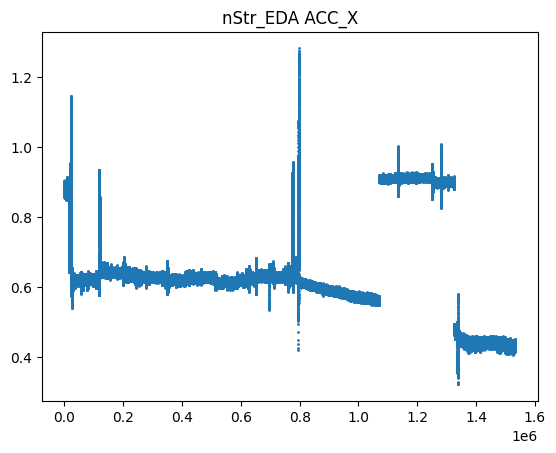

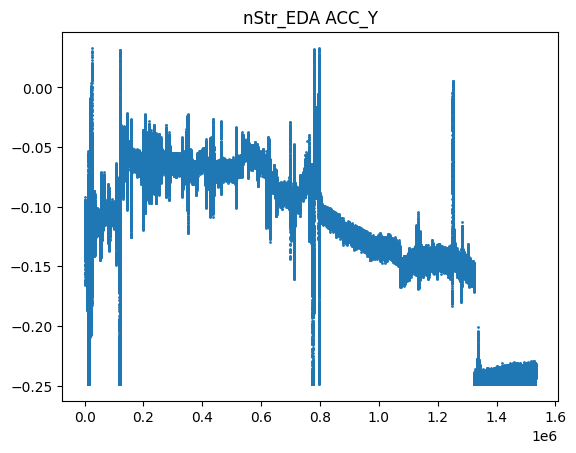

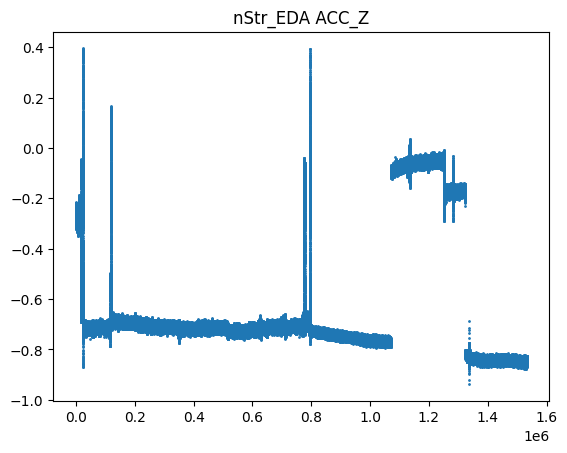

In [26]:
print(">---------- non stress class ---------<")
plt.scatter(range(len(nStr_EDA)), nStr_EDA["ACC_X"], s=1)
plt.title("nStr_EDA ACC_X")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ACC_Y"], s=1)
plt.title("nStr_EDA ACC_Y")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ACC_Z"], s=1)
plt.title("nStr_EDA ACC_Z")
plt.show()

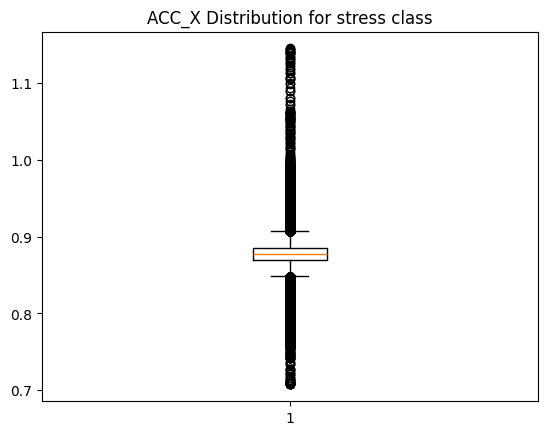

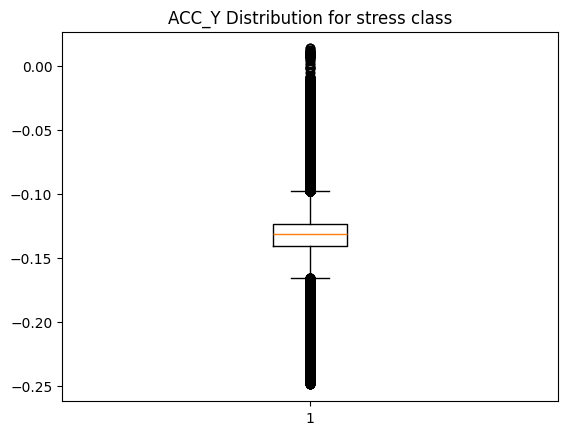

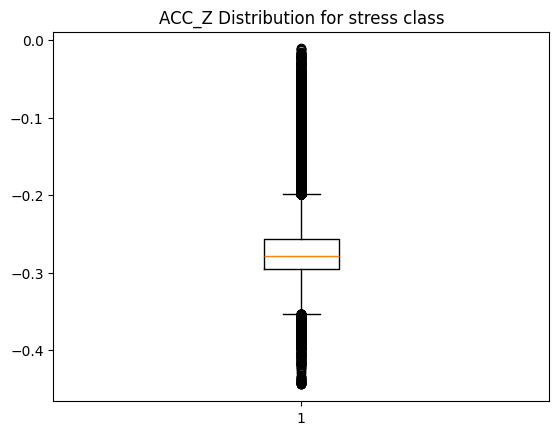

In [27]:
plt.boxplot(str_EDA["ACC_X"])
plt.title("ACC_X Distribution for stress class")
plt.show()

plt.boxplot(str_EDA["ACC_Y"])
plt.title("ACC_Y Distribution for stress class")
plt.show()

plt.boxplot(str_EDA["ACC_Z"])
plt.title("ACC_Z Distribution for stress class")
plt.show()

In [28]:
def boxplot_outlier(feature, dataset):
    while True:
        Q1 = dataset[feature].quantile(0.25)
        Q3 = dataset[feature].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        new_df = dataset[(dataset[feature] >= lower) & (dataset[feature] <= upper)]

        # stop when no more rows are removed
        if len(new_df) == len(dataset):
            break

        dataset = new_df
    return dataset

# Removing outliers of stress class

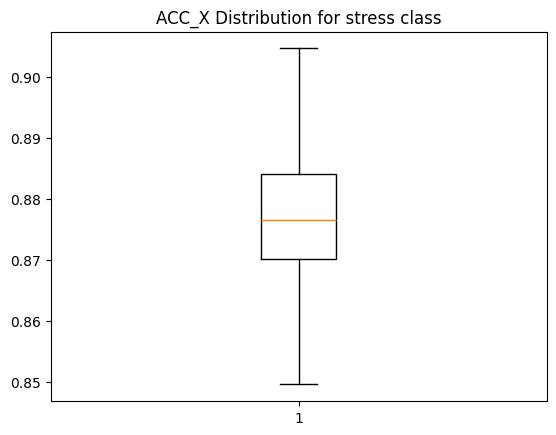

In [29]:
feature="ACC_X"
str_EDA = boxplot_outlier(feature=feature, dataset=str_EDA)

plt.boxplot(str_EDA[feature])
plt.title(f"{feature} Distribution for stress class")
plt.show()

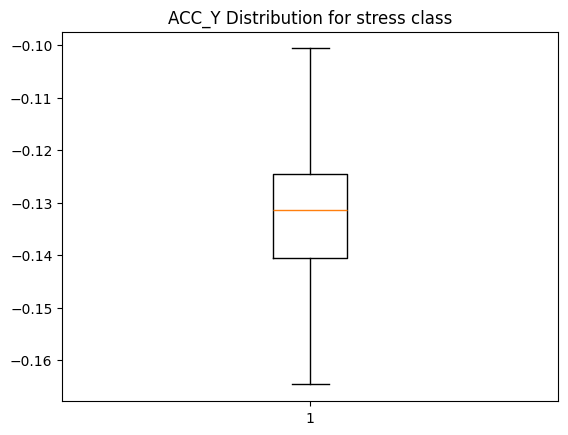

In [30]:
feature="ACC_Y"
str_EDA = boxplot_outlier(feature=feature, dataset=str_EDA)

plt.boxplot(str_EDA[feature])
plt.title(f"{feature} Distribution for stress class")
plt.show()

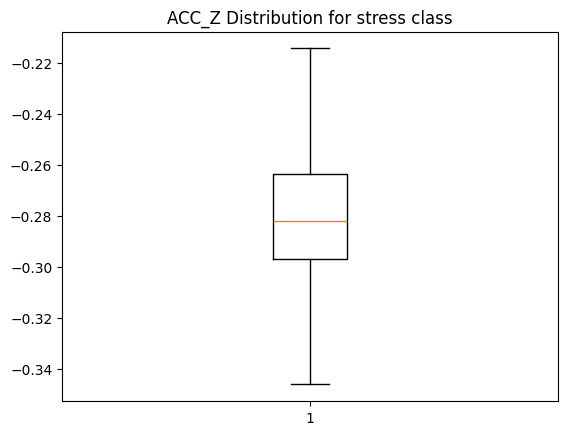

In [31]:
feature="ACC_Z"
str_EDA = boxplot_outlier(feature=feature, dataset=str_EDA)

plt.boxplot(str_EDA[feature])
plt.title(f"{feature} Distribution for stress class")
plt.show()

>---------- stress class ---------<


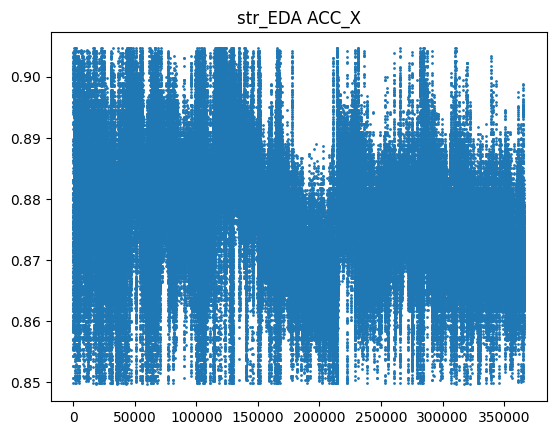

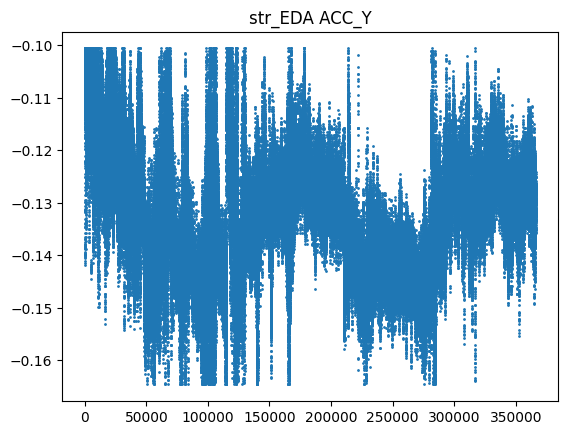

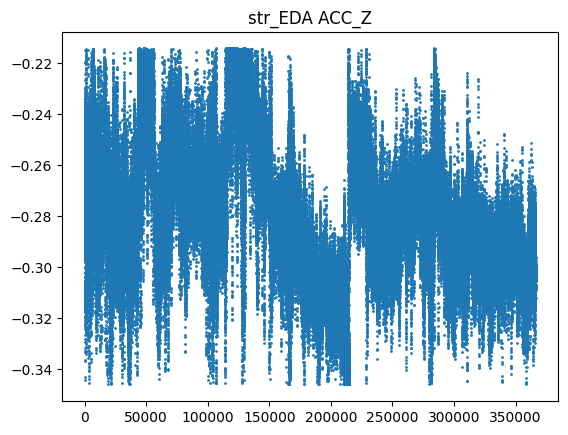

In [32]:
print(">---------- stress class ---------<")
plt.scatter(range(len(str_EDA)), str_EDA["ACC_X"], s=1)
plt.title("str_EDA ACC_X")
plt.show()

plt.scatter(range(len(str_EDA)), str_EDA["ACC_Y"], s=1)
plt.title("str_EDA ACC_Y")
plt.show()

plt.scatter(range(len(str_EDA)), str_EDA["ACC_Z"], s=1)
plt.title("str_EDA ACC_Z")
plt.show()

# Removing the outlier of non stress class

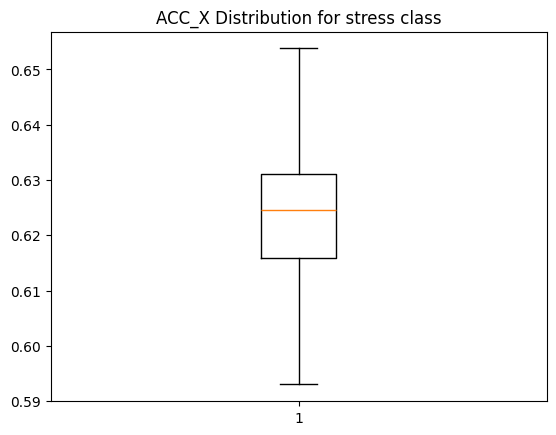

In [33]:
feature="ACC_X"
nStr_EDA = boxplot_outlier(feature=feature, dataset=nStr_EDA)

plt.boxplot(nStr_EDA[feature])
plt.title(f"{feature} Distribution for stress class")
plt.show()

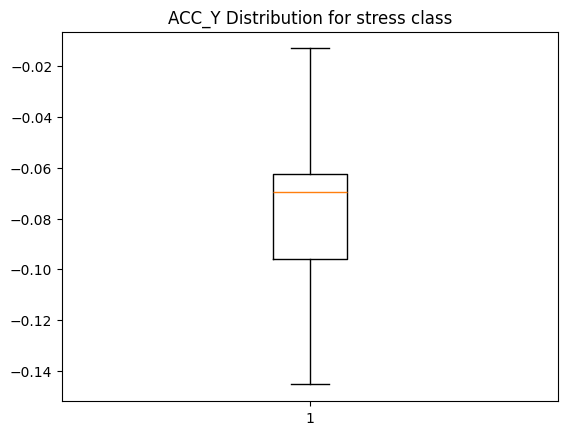

In [34]:
feature="ACC_Y"
nStr_EDA = boxplot_outlier(feature=feature, dataset=nStr_EDA)

plt.boxplot(nStr_EDA[feature])
plt.title(f"{feature} Distribution for stress class")
plt.show()

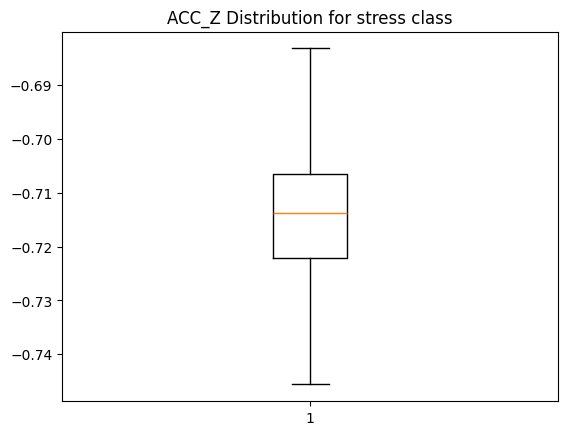

In [35]:
feature="ACC_Z"
nStr_EDA = boxplot_outlier(feature=feature, dataset=nStr_EDA)

plt.boxplot(nStr_EDA[feature])
plt.title(f"{feature} Distribution for stress class")
plt.show()

>---------- non stress class ---------<


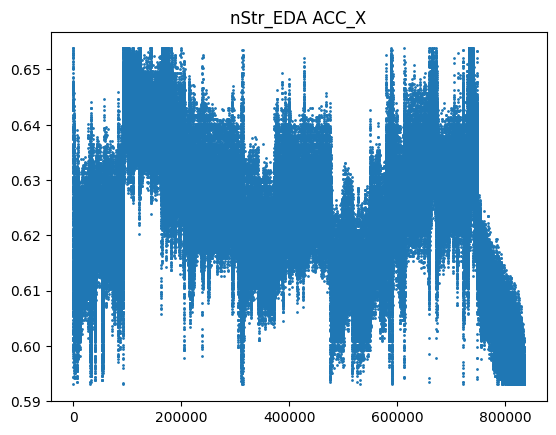

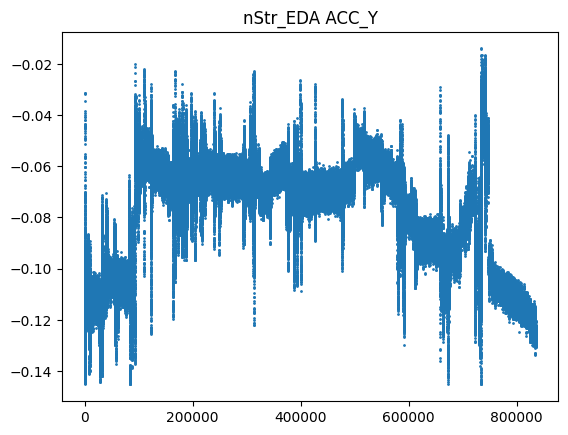

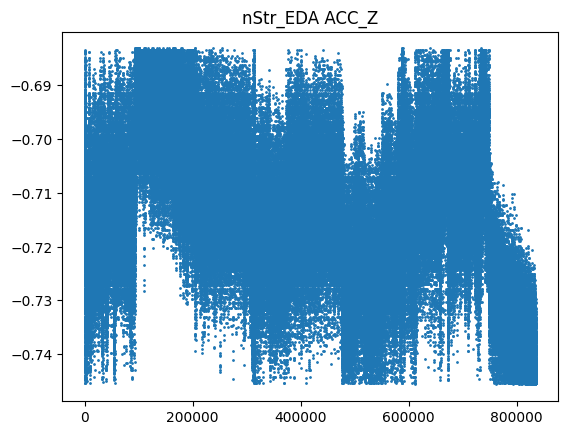

In [36]:
print(">---------- non stress class ---------<")
plt.scatter(range(len(nStr_EDA)), nStr_EDA["ACC_X"], s=1)
plt.title("nStr_EDA ACC_X")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ACC_Y"], s=1)
plt.title("nStr_EDA ACC_Y")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ACC_Z"], s=1)
plt.title("nStr_EDA ACC_Z")
plt.show()

# Final compassion

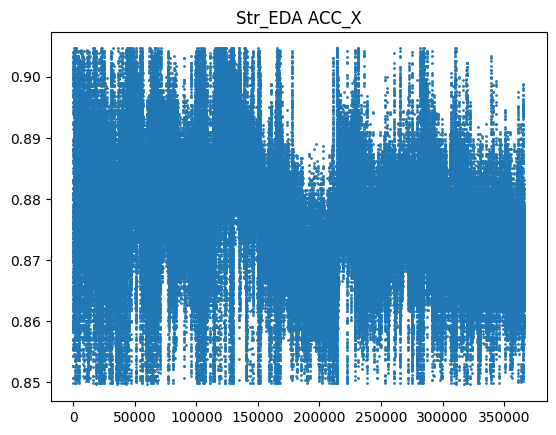

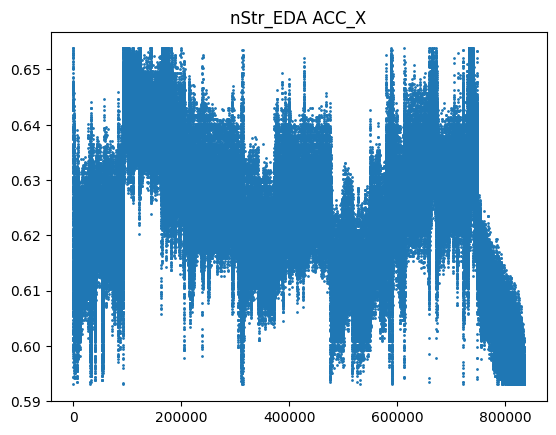

In [38]:
plt.scatter(range(len(str_EDA)), str_EDA["ACC_X"], s=1)
plt.title("Str_EDA ACC_X")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ACC_X"], s=1)
plt.title("nStr_EDA ACC_X")
plt.show()

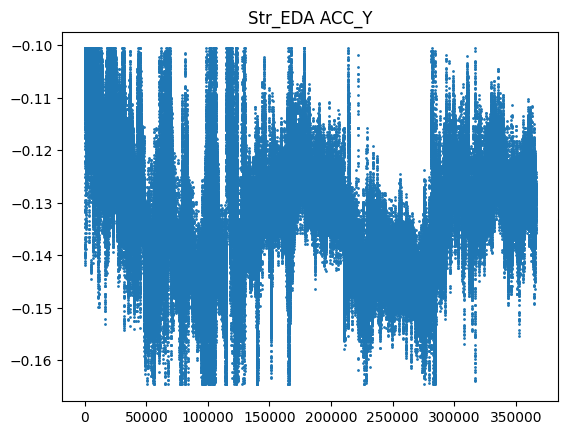

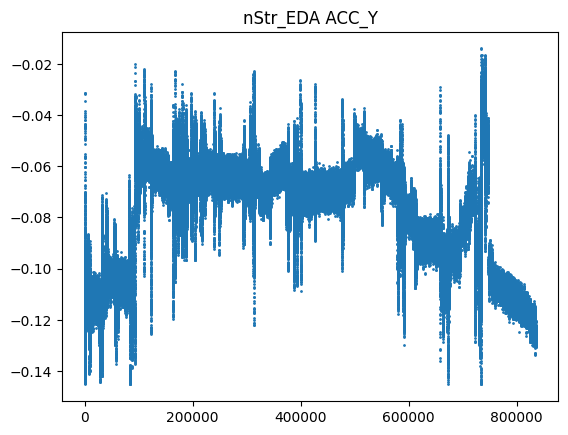

In [39]:
plt.scatter(range(len(str_EDA)), str_EDA["ACC_Y"], s=1)
plt.title("Str_EDA ACC_Y")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ACC_Y"], s=1)
plt.title("nStr_EDA ACC_Y")
plt.show()

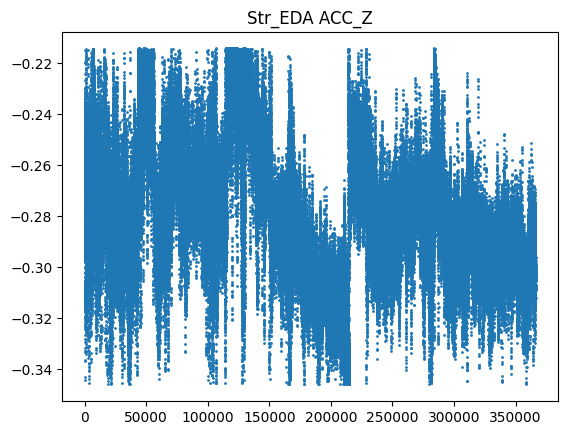

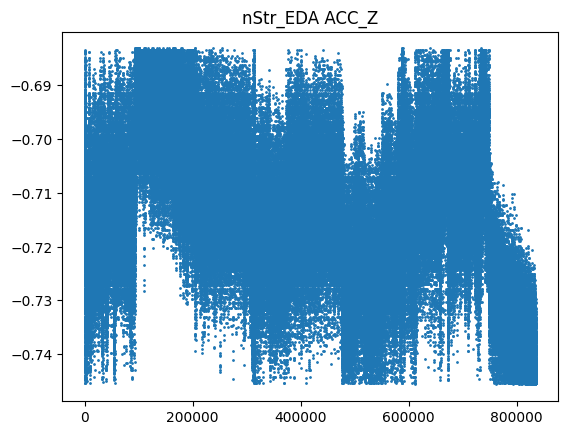

In [40]:
plt.scatter(range(len(str_EDA)), str_EDA["ACC_Z"], s=1)
plt.title("Str_EDA ACC_Z")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["ACC_Z"], s=1)
plt.title("nStr_EDA ACC_Z")
plt.show()